In [17]:
# import the data
import pandas as pd
income = pd.read_csv("MEHOINUSA646N.csv")
cpi = pd.read_csv("cpi_annual.csv")
# check the data
print(income.head())
print(cpi.head())
tail = income.tail()
print(tail)
tail = cpi.tail()
print(tail)

# clean the data
# rename CPI columns
cpi = cpi.rename(columns={
    "observation_date": "date",
    "CPIAUCSL": "cpi"
})
# drop the empty column
cpi = cpi[["date", "cpi"]]
cpi.head()

# convert date to datetime
cpi["date"] = pd.to_datetime(cpi["date"])
income["observation_date"] = pd.to_datetime(income["observation_date"])

# create year column
cpi["year"] = cpi["date"].dt.year
income["year"] = income["observation_date"].dt.year
cpi.head()

  observation_date  MEHOINUSA646N
0       1984-01-01          22420
1       1985-01-01          23620
2       1986-01-01          24900
3       1987-01-01          26060
4       1988-01-01          27230
  observation_date  CPIAUCSL  Unnamed: 2
0           1/1/47    22.332         NaN
1           1/1/48    24.045         NaN
2           1/1/49    23.809         NaN
3           1/1/50    24.063         NaN
4           1/1/51    25.973         NaN
   observation_date  MEHOINUSA646N
35       2019-01-01          68700
36       2020-01-01          68010
37       2021-01-01          70780
38       2022-01-01          74580
39       2023-01-01          80610
   observation_date  CPIAUCSL  Unnamed: 2
73           1/1/20   258.846         NaN
74           1/1/21   270.966         NaN
75           1/1/22   292.621         NaN
76           1/1/23   304.701         NaN
77           1/1/24   313.698         NaN


/var/folders/8s/fmp72fxn76d8vczwqmy1bbjc0000gn/T/ipykernel_72213/3537480513.py:24: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  cpi["date"] = pd.to_datetime(cpi["date"])


,date,cpi,year
0,2047-01-01,22.332,2047
1,2048-01-01,24.045,2048
2,2049-01-01,23.809,2049
3,2050-01-01,24.063,2050
4,2051-01-01,25.973,2051


In [18]:
# Fix CPI date (2047 -> 1947) by shifting dates back 100 years when needed

# 1) parse date
cpi["date"] = pd.to_datetime(cpi["date"], errors="coerce")

# 2) identify wrongly-parsed 20xx dates and shift back 100 years
mask = cpi["date"].dt.year > 2025
cpi.loc[mask, "date"] = cpi.loc[mask, "date"] - pd.DateOffset(years=100)

# 3) rebuild year from the corrected date
cpi["year"] = cpi["date"].dt.year

cpi.head()

,date,cpi,year
0,1947-01-01,22.332,1947
1,1948-01-01,24.045,1948
2,1949-01-01,23.809,1949
3,1950-01-01,24.063,1950
4,1951-01-01,25.973,1951


In [19]:
# Calculate price index (base year = first year)

# find base CPI (earliest year)
base_cpi = cpi.loc[cpi["year"] == cpi["year"].min(), "cpi"].iloc[0]

# create price index
cpi["price_index"] = (cpi["cpi"] / base_cpi) * 100

cpi.head()

,date,cpi,year,price_index
0,1947-01-01,22.332,1947,100.000000
1,1948-01-01,24.045,1948,107.670607
2,1949-01-01,23.809,1949,106.613828
3,1950-01-01,24.063,1950,107.751209
4,1951-01-01,25.973,1951,116.303958


In [20]:
# merge CPI data with household income data
merged = pd.merge(income, cpi[["year", "price_index"]], on="year", how="left")
merged.head()

# clean column names (make dataset readable)
merged = merged.rename(columns={
    "observation_date": "date",
    "MEHOINUSA646N": "nominal_income"
})

merged.head()

,date,nominal_income,year,price_index
0,1984-01-01,22420,1984,465.399427
1,1985-01-01,23620,1985,481.819810
2,1986-01-01,24900,1986,491.187534
3,1987-01-01,26060,1987,508.763210
4,1988-01-01,27230,1988,529.621171


In [21]:
# Convert nominal income to real income using the price index
merged["real_income"] = merged["nominal_income"] / (merged["price_index"] / 100)
merged.head()   

,date,nominal_income,year,price_index,real_income
0,1984-01-01,22420,1984,465.399427,4817.367342
1,1985-01-01,23620,1985,481.819810,4902.247584
2,1986-01-01,24900,1986,491.187534,5069.346899
3,1987-01-01,26060,1987,508.763210,5122.225723
4,1988-01-01,27230,1988,529.621171,5141.410780


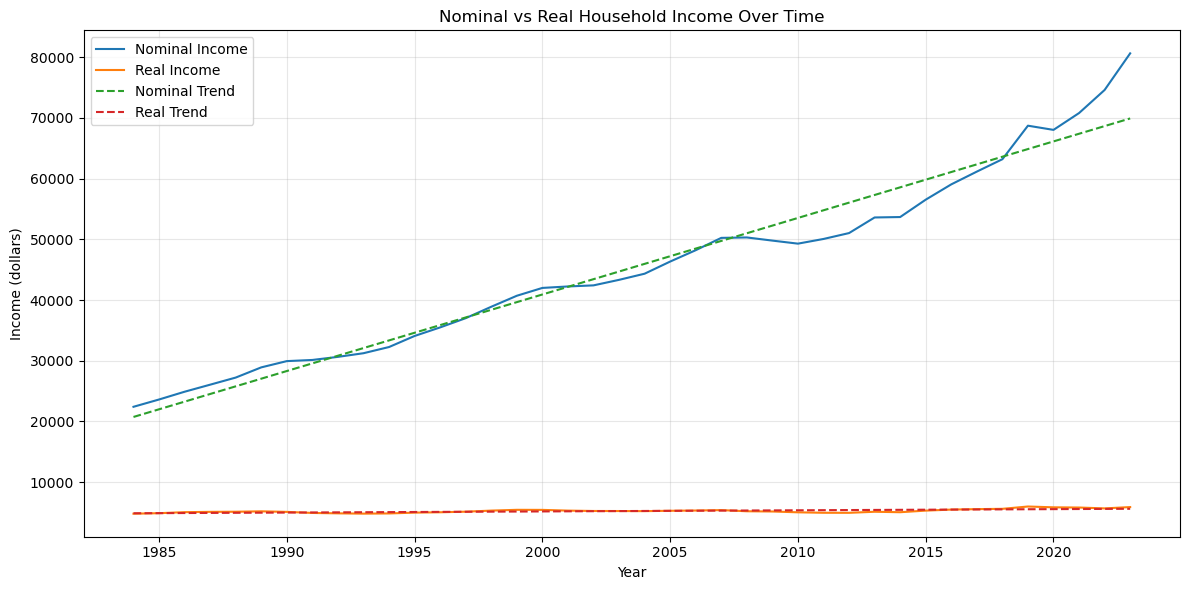

In [22]:
# Generate the plot of real income and nominal income over time with fitted trend lines
import numpy as np
import matplotlib.pyplot as plt

# make sure sorted
merged = merged.sort_values("year")

x = merged["year"].values
y_nom = merged["nominal_income"].values
y_real = merged["real_income"].values

# linear trend lines
trend_nom = np.poly1d(np.polyfit(x, y_nom, 1))(x)
trend_real = np.poly1d(np.polyfit(x, y_real, 1))(x)

plt.figure(figsize=(12,6))

plt.plot(x, y_nom, label="Nominal Income")
plt.plot(x, y_real, label="Real Income")

plt.plot(x, trend_nom, linestyle="--", label="Nominal Trend")
plt.plot(x, trend_real, linestyle="--", label="Real Trend")

plt.title("Nominal vs Real Household Income Over Time")
plt.xlabel("Year")
plt.ylabel("Income (dollars)")
plt.legend()
plt.tight_layout()
plt.grid(alpha=0.3)
plt.show()